# FineBio — Multi-View Least-Squares 3D Localization
Builds a shared Euclidean space from all 5 third-person cameras calibrated to the same board frame.
For each object at each frame, casts rays from every camera that detects it and solves for the
3D point minimizing distance to all rays simultaneously. The fp camera contributes per-frame rays.
Output: stable per-object 3D positions in board space, updated every frame.

## 1. Install dependencies

In [1]:
!pip install opencv-python numpy matplotlib tqdm ultralytics -q

## 2. Config

In [ ]:
from pathlib import Path
import numpy as np

FINEBIO_ROOT = Path("/home/nyan/FineBio")
CAL_ROOT     = FINEBIO_ROOT / "14 misc/finebio_camera_poses/finebio_camera_poses"
YOLO_WEIGHTS = Path("./runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt")

TRIAL_DATE   = "221207"
TRIAL_ID     = "P01_01_01"
TP_CAM_IDS   = [1, 2, 3, 4, 6]   # NOTE: no cam 5, jumps to 6

CONF_THRESH  = 0.3
HAND_CLASSES = ["left_hand", "right_hand", "hand"]

# Frame paths for your trial — {cam_id: directory of frames}
# Adjust to match your actual FineBio directory structure
FRAME_DIRS = {
    1   : FINEBIO_ROOT / "frames" / TRIAL_ID / "cam1",
    2   : FINEBIO_ROOT / "frames" / TRIAL_ID / "cam2",
    3   : FINEBIO_ROOT / "frames" / TRIAL_ID / "cam3",
    4   : FINEBIO_ROOT / "frames" / TRIAL_ID / "cam4",
    6   : FINEBIO_ROOT / "frames" / TRIAL_ID / "cam6",
    "fp": FINEBIO_ROOT / "frames" / TRIAL_ID / "fp",
}

print("Config set.")

Config set.


## 3. Camera loader — all cameras into shared board frame

In [ ]:
import cv2

def load_intrinsics(npz_path):
    data = np.load(npz_path)
    K    = data["intrinsic_matrix"].astype(np.float64)
    dist = data["distCoeff"].astype(np.float64).flatten()
    assert K.shape == (3, 3)
    assert dist.size in [4, 5, 8, 12, 14]
    return K, dist


def load_extrinsics(npz_path):
    data = np.load(npz_path)
    keys = set(data.files)

    # Some FineBio calibration dumps store Rodrigues + translation as 'rvec'/'tvec',
    # others store the same values as 'r'/'t'. Support both.
    if "rvec" in keys:
        rvec = data["rvec"]
    elif "r" in keys:
        rvec = data["r"]
    else:
        raise KeyError(f"Extrinsics missing rvec/r keys. Keys: {list(data.files)} ({npz_path})")

    if "tvec" in keys:
        tvec = data["tvec"]
    elif "t" in keys:
        tvec = data["t"]
    else:
        raise KeyError(f"Extrinsics missing tvec/t keys. Keys: {list(data.files)} ({npz_path})")

    rvec = np.asarray(rvec).flatten()
    tvec = np.asarray(tvec).flatten()

    R, _ = cv2.Rodrigues(rvec.reshape(3, 1))
    t = tvec.reshape(3, 1)
    return R.astype(np.float64), t.astype(np.float64)


def build_projection_matrix(K, R, t):
    return (K @ np.hstack([R, t])).astype(np.float64)


def load_static_cameras(cal_root, trial_date, tp_cam_ids):
    """
    Load all third-person cameras into the shared board coordinate frame.
    Returns {cam_id: {K, dist, R, t, P, pos_world}}
    """
    K_tp, dist_tp = load_intrinsics(
        cal_root / "intrinsic_parameters" / "gopro9_6_linear_4k_169_0.50.npz"
    )
    cameras = {}
    for cam_id in tp_cam_ids:
        ext_path = cal_root / "third_person_camera_poses" / trial_date / "extrinsics" / f"{cam_id}_board.npz"
        R, t = load_extrinsics(ext_path)
        pos  = (-R.T @ t).flatten()   # camera centre in world coords
        cameras[cam_id] = {
            "K"        : K_tp,
            "dist"     : dist_tp,
            "R"        : R,
            "t"        : t,
            "P"        : build_projection_matrix(K_tp, R, t),
            "pos_world": pos,
        }
        print(f"  Cam {cam_id}: world pos = ({pos[0]:.1f}, {pos[1]:.1f}, {pos[2]:.1f})")
    return cameras


def load_fp_intrinsics(cal_root):
    return load_intrinsics(
        cal_root / "intrinsic_parameters" / "gopro9_5_wide_4k_43_0.50.npz"
    )


def get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx):
    """
    Resolve fp camera pose at a specific frame index.
    Handles rvecs/tvecs, poses (4x4), or R/t array formats.
    """
    if "rvecs" in fp_npz.files:
        rvec = fp_npz["rvecs"][frame_idx].reshape(3, 1)
        tvec = fp_npz["tvecs"][frame_idx].reshape(3, 1)
        R, _ = cv2.Rodrigues(rvec)
        t    = tvec
    elif "poses" in fp_npz.files:
        T = fp_npz["poses"][frame_idx]
        R = T[:3, :3]
        t = T[:3, 3:4]
    elif "R" in fp_npz.files:
        R = fp_npz["R"][frame_idx]
        t = fp_npz["t"][frame_idx].reshape(3, 1)
    else:
        print(f"Unknown fp pose format. Keys: {fp_npz.files}")
        return None

    R = R.astype(np.float64)
    t = t.astype(np.float64)
    return {
        "K"        : K_fp,
        "dist"     : dist_fp,
        "R"        : R,
        "t"        : t,
        "P"        : build_projection_matrix(K_fp, R, t),
        "pos_world": (-R.T @ t).flatten(),
    }


# Load everything
static_cameras = load_static_cameras(CAL_ROOT, TRIAL_DATE, TP_CAM_IDS)
K_fp, dist_fp  = load_fp_intrinsics(CAL_ROOT)
fp_npz         = np.load(CAL_ROOT / "first_person_camera_poses" / f"{TRIAL_ID}.npz")

print(f"\nLoaded {len(static_cameras)} static cameras.")
print(f"FP pose keys: {list(fp_npz.files)}")

  Cam 1: world pos = (-67.7, -42.0, -59.0)
  Cam 2: world pos = (92.8, -36.3, -63.3)
  Cam 3: world pos = (-68.5, 27.7, -55.6)
  Cam 4: world pos = (93.4, 33.1, -62.6)
  Cam 6: world pos = (9.6, 8.4, -86.8)

Loaded 5 static cameras.
FP pose keys: ['rets', 'rots', 'trans']


## 4. Visualise camera layout in shared world frame
Sanity check — all cameras should surround the board origin.

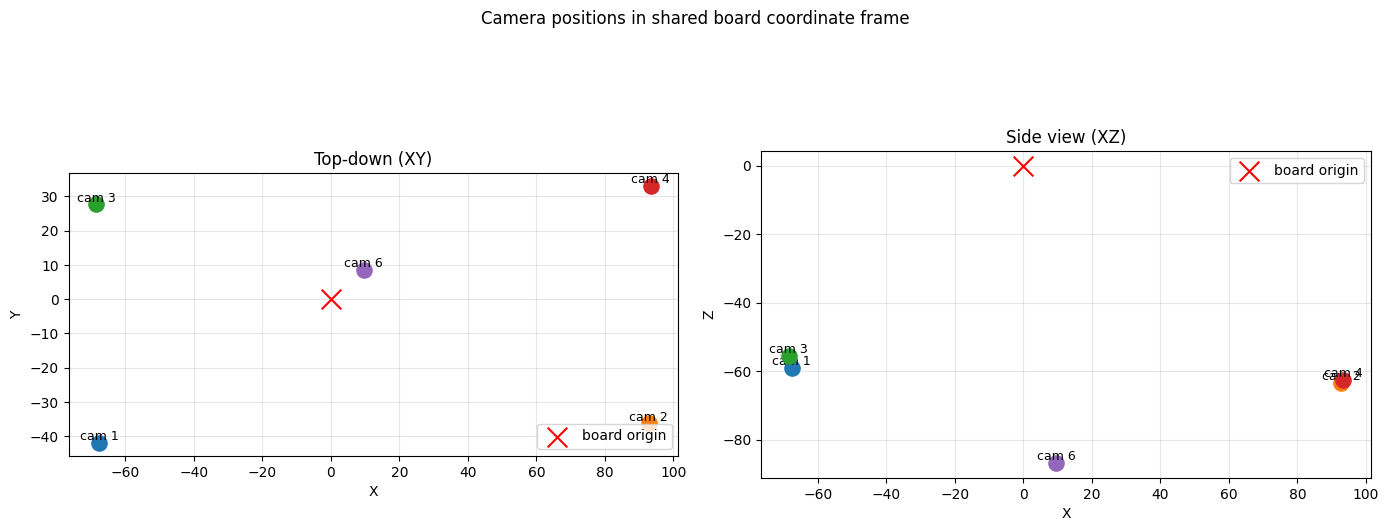

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top-down XY
ax = axes[0]
for cam_id, cam in static_cameras.items():
    x, y, z = cam["pos_world"]
    ax.scatter(x, y, s=120, zorder=3)
    ax.annotate(f"cam {cam_id}", (x, y), fontsize=9, ha="center", va="bottom")
ax.scatter(0, 0, s=200, marker="x", color="red", zorder=4, label="board origin")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title("Top-down (XY)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect("equal")

# Side XZ
ax = axes[1]
for cam_id, cam in static_cameras.items():
    x, y, z = cam["pos_world"]
    ax.scatter(x, z, s=120, zorder=3)
    ax.annotate(f"cam {cam_id}", (x, z), fontsize=9, ha="center", va="bottom")
ax.scatter(0, 0, s=200, marker="x", color="red", zorder=4, label="board origin")
ax.set_xlabel("X"); ax.set_ylabel("Z")
ax.set_title("Side view (XZ)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect("equal")

plt.suptitle("Camera positions in shared board coordinate frame", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Core — least-squares ray intersection
For N cameras each seeing an object at 2D point p_i, cast a ray from each camera centre
through p_i and find the 3D point X minimizing sum of squared distances to all rays.
This is a standard linear system — fast, robust, degrades gracefully with fewer views.

In [33]:
def pixel_to_ray(pt_2d, K, dist, R, t):
    """
    Given a 2D pixel observation, return the ray in world coordinates:
    origin (camera centre) and unit direction vector.
    """
    # Undistort the point
    pt = np.array([[pt_2d]], dtype=np.float64)
    pt_undist = cv2.undistortPoints(pt, K, dist, P=K)[0][0]

    # Ray direction in camera space: K^-1 * [u, v, 1]
    K_inv     = np.linalg.inv(K)
    ray_cam   = K_inv @ np.array([pt_undist[0], pt_undist[1], 1.0])

    # Rotate to world space
    ray_world = R.T @ ray_cam
    ray_world = ray_world / np.linalg.norm(ray_world)   # unit vector

    # Camera centre in world
    origin = (-R.T @ t).flatten()

    return origin, ray_world


def least_squares_ray_intersection(rays):
    """
    rays: list of (origin, direction) tuples — one per camera that sees the object.

    Solves for X = argmin sum_i ||X - closest_point_on_ray_i||^2
    using the closed-form linear solution.

    Each ray contributes: (I - d*d^T) X = (I - d*d^T) o
    Stacking all rays gives A X = b — solve via least squares.

    Returns: (X, mean_ray_distance)
    """
    A = np.zeros((3, 3))
    b = np.zeros(3)

    for origin, direction in rays:
        d  = direction.reshape(3, 1)
        o  = origin.reshape(3, 1)
        M  = np.eye(3) - d @ d.T     # projection onto plane perpendicular to ray
        A += M
        b += (M @ o).flatten()

    X, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    # Compute mean distance from X to each ray (quality metric)
    dists = []
    for origin, direction in rays:
        diff = X - origin
        proj = np.dot(diff, direction)
        closest = origin + proj * direction
        dists.append(np.linalg.norm(X - closest))
    mean_dist = float(np.mean(dists))

    return X, mean_dist


print("Ray intersection functions defined.")

Ray intersection functions defined.


## 6. YOLO26 detection across all views

In [34]:
from ultralytics import YOLO
from pathlib import Path

model     = YOLO(str(YOLO_WEIGHTS))
cat_names = model.names
hand_cls_ids = {k for k, v in cat_names.items() if v.lower() in HAND_CLASSES}
print(f"Hand class indices: {hand_cls_ids}")
print(f"Total classes: {len(cat_names)}")


def get_frame_path(frame_dir, frame_idx):
    """
    Find the frame image for a given index.
    Handles both zero-padded naming (frame_0100.jpg) and plain (100.jpg).
    """
    candidates = sorted(Path(frame_dir).glob("*.jpg")) + \
                 sorted(Path(frame_dir).glob("*.png"))
    if frame_idx < len(candidates):
        return candidates[frame_idx]
    return None


def detect_frame(img_path, model, conf=CONF_THRESH):
    result = model(img_path, conf=conf, verbose=False)[0]
    detections = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        detections.append({
            "cls_id"     : cls_id,
            "cls_name"   : cat_names[cls_id],
            "conf"       : float(box.conf[0]),
            "bbox_xyxy"  : [x1, y1, x2, y2],
            "bbox_center": [(x1 + x2) / 2, (y1 + y2) / 2],
        })
    return detections


def detect_all_views(frame_idx, frame_dirs, model):
    """
    Run YOLO on all cameras for a given frame index.
    Returns {cam_id: [detections]}
    """
    all_dets = {}
    for cam_id, frame_dir in frame_dirs.items():
        img_path = get_frame_path(frame_dir, frame_idx)
        if img_path is None or not img_path.exists():
            all_dets[cam_id] = []
            continue
        all_dets[cam_id] = detect_frame(img_path, model)
        n = len(all_dets[cam_id])
        print(f"  Cam {cam_id}: {n} detections  ({img_path.name})")
    return all_dets


# Test on frame 100
FRAME_IDX    = 100
all_dets     = detect_all_views(FRAME_IDX, FRAME_DIRS, model)

Hand class indices: {0, 1}
Total classes: 35


## 7. Multi-view 3D localisation — one object at a time
For each class, gather all detections across all views and cast rays into the shared world frame.

In [35]:
def get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx):
    R = fp_npz["rots"][frame_idx].astype(np.float64)   # shape (3,3)
    t = fp_npz["trans"][frame_idx].astype(np.float64).reshape(3, 1)
    return {
        "K"        : K_fp,
        "dist"     : dist_fp,
        "R"        : R,
        "t"        : t,
        "P"        : build_projection_matrix(K_fp, R, t),
        "pos_world": (-R.T @ t).flatten(),
    }

In [36]:
# Check what's actually in your frame directories
for cam_id, frame_dir in FRAME_DIRS.items():
    p = Path(frame_dir)
    files = list(p.glob("*.jpg")) + list(p.glob("*.png"))
    print(f"Cam {cam_id}: {len(files)} files in {p}")
    if files:
        print(f"  First file: {files[0].name}")

Cam 1: 0 files in /home/nyan/FineBio/frames/P01_01_01/cam1
Cam 2: 0 files in /home/nyan/FineBio/frames/P01_01_01/cam2
Cam 3: 0 files in /home/nyan/FineBio/frames/P01_01_01/cam3
Cam 4: 0 files in /home/nyan/FineBio/frames/P01_01_01/cam4
Cam 6: 0 files in /home/nyan/FineBio/frames/P01_01_01/cam6
Cam fp: 0 files in /home/nyan/FineBio/frames/P01_01_01/fp


In [37]:
# Find the actual structure
import os
for root, dirs, files in os.walk("/home/nyan/FineBio"):
    # Skip the calibration folder we already know
    dirs[:] = [d for d in dirs if "misc" not in d and "camera_poses" not in d]
    depth = root.replace("/home/nyan/FineBio", "").count(os.sep)
    if depth > 3:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 3:
        # Show a sample of files at this level
        sample = files[:3]
        for f in sample:
            print(f"{indent}  {f}")

FineBio/
  05 finebio_videos_tpv_train/
    finebio_videos/
  10 finebio_videos_tpv_all_w640/
    finebio_videos_w640/
  01 annotations/
    finebio_coco_annotations/
    finebio_action_annotations/
  03 finebio_videos_fpv_all_w640/
  04 finebio_videos_fpv_test/
  All Zip/
  13 features/
  11 finebio_videos_fpv_valid/
    finebio_videos/
  09 finebio_videos_fpv_train/
    finebio_videos/
  08 finebio_videos_tpv_test/
    finebio_videos/
  12 finebio_object_detection_images/
    finebio_object_detection_images/
  02 ckpts/
  06 finebio_videos_tpv_valid/
    finebio_videos/
  07 finebio_mistake_trials/
    finebio_mistake_trials/


In [38]:
import os
from pathlib import Path

# Check TPV and FPV video structure
for folder in ["05 finebio_videos_tpv_train/finebio_videos", 
               "09 finebio_videos_fpv_train/finebio_videos"]:
    p = Path("/home/nyan/FineBio") / folder
    files = sorted(p.glob("**/*.mp4")) + sorted(p.glob("**/*.MP4")) + \
            sorted(p.glob("**/*.mov")) + sorted(p.glob("**/*.MOV"))
    print(f"\n{folder}: {len(files)} videos")
    for f in files[:5]:
        print(f"  {f.relative_to(p)}")


05 finebio_videos_tpv_train/finebio_videos: 785 videos
  P01_01_01_T1.mp4
  P01_01_01_T2.mp4
  P01_01_01_T3.mp4
  P01_01_01_T4.mp4
  P01_01_01_T5.mp4

09 finebio_videos_fpv_train/finebio_videos: 161 videos
  P01_01_01.mp4
  P01_01_02.mp4
  P01_02_01.mp4
  P01_02_02.mp4
  P01_03_01.mp4


In [40]:
from pathlib import Path

# Find all video files under the TPV train folder
tpv = Path("/home/nyan/FineBio/05 finebio_videos_tpv_train")
videos = list(tpv.rglob("*.mp4"))[:5]
for v in videos:
    print(v)

# Also check full res TPV all folder
tpv_all = Path("/home/nyan/FineBio/08 finebio_videos_tpv_test")
videos2 = list(tpv_all.rglob("*.mp4"))[:3]
for v in videos2:
    print(v)

/home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos/P29_07_01_T1.mp4
/home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos/P02_01_02_T4.mp4
/home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos/P21_02_01_T1.mp4
/home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos/P27_05_01_T3.mp4
/home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos/P14_02_01_T3.mp4
/home/nyan/FineBio/08 finebio_videos_tpv_test/finebio_videos/P28_07_01_T3.mp4
/home/nyan/FineBio/08 finebio_videos_tpv_test/finebio_videos/P08_02_01_T2.mp4
/home/nyan/FineBio/08 finebio_videos_tpv_test/finebio_videos/P28_05_02_T5.mp4


In [21]:
def localise_all_objects(all_dets, static_cameras, fp_cam, hand_cls_ids, cat_names):
    """
    For every detected object class, collect rays from all cameras that see it
    and solve for 3D position via least-squares ray intersection.

    Returns: {
        cls_name: {
            pos3d       : np.array([X, Y, Z]) in board space,
            mean_ray_dist: float (quality — lower is better),
            n_views     : int,
            contributing_cams: [cam_ids],
            best_det    : detection dict from highest-conf view
        }
    }
    """
    # Group detections by class across all cameras
    # For each class, keep best detection per camera (highest conf)
    class_to_rays  = {}   # cls_name -> [(origin, direction, cam_id, conf)]
    class_best_det = {}   # cls_name -> best detection dict

    for cam_id, dets in all_dets.items():
        # Resolve camera matrix for this cam
        if cam_id == "fp":
            cam = fp_cam
        else:
            cam = static_cameras.get(cam_id)
        if cam is None:
            continue

        # Keep only best detection per class per camera
        best_per_class = {}
        for det in dets:
            if det["cls_id"] in hand_cls_ids:
                continue
            cls = det["cls_name"]
            if cls not in best_per_class or det["conf"] > best_per_class[cls]["conf"]:
                best_per_class[cls] = det

        for cls, det in best_per_class.items():
            try:
                origin, direction = pixel_to_ray(
                    det["bbox_center"],
                    cam["K"], cam["dist"], cam["R"], cam["t"]
                )
                class_to_rays.setdefault(cls, []).append(
                    (origin, direction, cam_id, det["conf"])
                )
                # Track best detection overall (highest conf)
                if cls not in class_best_det or det["conf"] > class_best_det[cls]["conf"]:
                    class_best_det[cls] = {**det, "cam_id": cam_id}
            except Exception as e:
                print(f"  Ray error for {cls} cam {cam_id}: {e}")

    # Solve for 3D position per class
    results = {}
    for cls, ray_list in class_to_rays.items():
        rays            = [(o, d) for o, d, _, _ in ray_list]
        contributing    = [c for _, _, c, _ in ray_list]

        if len(rays) == 1:
            # Single ray — no intersection possible, store None
            results[cls] = {
                "pos3d"           : None,
                "mean_ray_dist"   : None,
                "n_views"         : 1,
                "contributing_cams": contributing,
                "best_det"        : class_best_det[cls],
            }
        else:
            pos3d, mean_dist = least_squares_ray_intersection(rays)
            results[cls] = {
                "pos3d"           : pos3d,
                "mean_ray_dist"   : mean_dist,
                "n_views"         : len(rays),
                "contributing_cams": contributing,
                "best_det"        : class_best_det[cls],
            }

    return results


# Resolve fp camera for this frame
fp_cam = get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx=FRAME_IDX)

# Localise
object_positions = localise_all_objects(
    all_dets, static_cameras, fp_cam, hand_cls_ids, cat_names
)

# Print results
print(f"\nLocalised {len(object_positions)} objects:")
print(f"{'Object':<30} {'X':>8} {'Y':>8} {'Z':>8} {'ray_err':>8} {'views':>6} {'cams'}")
print("-" * 85)
for cls, res in sorted(object_positions.items()):
    if res["pos3d"] is not None:
        X, Y, Z = res["pos3d"]
        print(f"{cls:<30} {X:>8.1f} {Y:>8.1f} {Z:>8.1f} "
              f"{res['mean_ray_dist']:>8.2f} {res['n_views']:>6}  {res['contributing_cams']}")
    else:
        print(f"{cls:<30} {'N/A':>8} {'N/A':>8} {'N/A':>8} "
              f"{'N/A':>8} {res['n_views']:>6}  {res['contributing_cams']} (single view)")


Localised 0 objects:
Object                                X        Y        Z  ray_err  views cams
-------------------------------------------------------------------------------------


## 8. Quality check — ray distance distribution
Mean ray distance tells us how consistent the detections are across views.
Low = cameras agree. High = noisy detection or wrong class match across views.

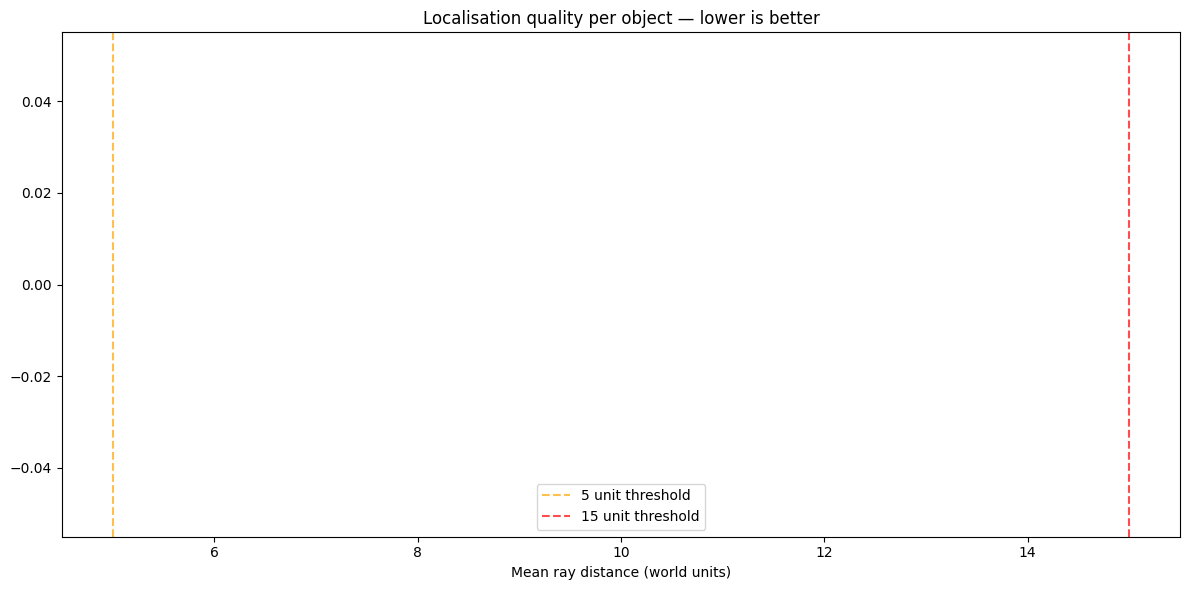

Objects with ray_dist < 5  (good)    : 0
Objects with ray_dist 5-15 (ok)      : 0
Objects with ray_dist > 15 (poor)    : 0


In [14]:
import matplotlib.pyplot as plt

names  = []
dists  = []
nviews = []

for cls, res in object_positions.items():
    if res["mean_ray_dist"] is not None:
        names.append(cls)
        dists.append(res["mean_ray_dist"])
        nviews.append(res["n_views"])

# Sort by ray distance
order  = sorted(range(len(dists)), key=lambda i: dists[i])
names  = [names[i]  for i in order]
dists  = [dists[i]  for i in order]
nviews = [nviews[i] for i in order]

colors = ["steelblue" if d < 5 else "orange" if d < 15 else "red" for d in dists]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(names, dists, color=colors)
for i, (d, n) in enumerate(zip(dists, nviews)):
    ax.text(d + 0.1, i, f"{n} views", va="center", fontsize=8)
ax.axvline(5,  color="orange", linestyle="--", alpha=0.7, label="5 unit threshold")
ax.axvline(15, color="red",    linestyle="--", alpha=0.7, label="15 unit threshold")
ax.set_xlabel("Mean ray distance (world units)")
ax.set_title("Localisation quality per object — lower is better")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Objects with ray_dist < 5  (good)    : {sum(1 for d in dists if d < 5)}")
print(f"Objects with ray_dist 5-15 (ok)      : {sum(1 for d in dists if 5 <= d < 15)}")
print(f"Objects with ray_dist > 15 (poor)    : {sum(1 for d in dists if d >= 15)}")

## 9. Visualise 3D bench layout — top-down and side views

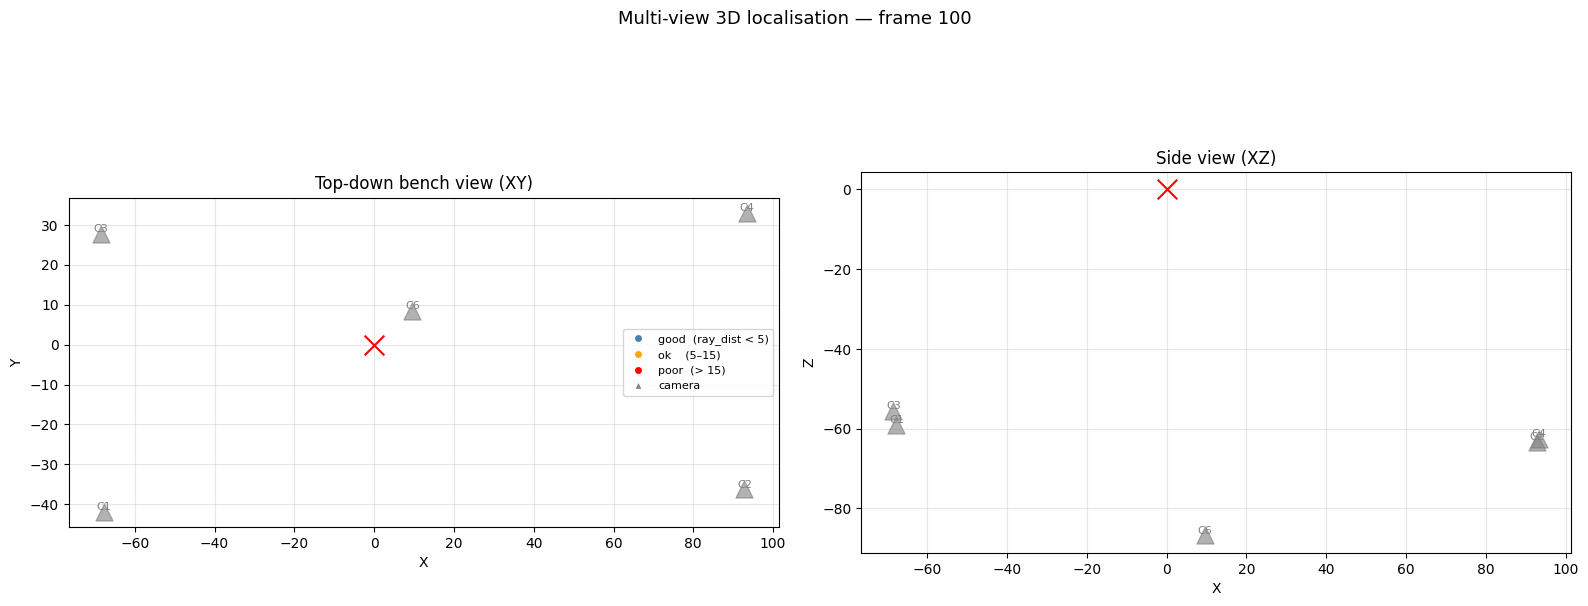

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (dim_a, dim_b, xlabel, ylabel, title) in zip(axes, [
    (0, 1, "X", "Y", "Top-down bench view (XY)"),
    (0, 2, "X", "Z", "Side view (XZ)"),
]):
    # Camera positions
    for cam_id, cam in static_cameras.items():
        pos = cam["pos_world"]
        ax.scatter(pos[dim_a], pos[dim_b], s=150, marker="^",
                   color="gray", zorder=4, alpha=0.6)
        ax.annotate(f"C{cam_id}", (pos[dim_a], pos[dim_b]),
                    fontsize=8, color="gray", ha="center", va="bottom")

    # Board origin
    ax.scatter(0, 0, s=200, marker="x", color="red", zorder=5, label="board origin")

    # Object positions — colour by quality
    for cls, res in object_positions.items():
        if res["pos3d"] is None:
            continue
        X, Y, Z = res["pos3d"]
        coord_a  = [X, Y, Z][dim_a]
        coord_b  = [X, Y, Z][dim_b]
        d        = res["mean_ray_dist"]
        color    = "steelblue" if d < 5 else "orange" if d < 15 else "red"
        ax.scatter(coord_a, coord_b, s=80, color=color, zorder=3)
        ax.annotate(cls, (coord_a, coord_b),
                    fontsize=6, ha="center", va="bottom")

    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="steelblue", label="good  (ray_dist < 5)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="orange",    label="ok    (5–15)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="red",       label="poor  (> 15)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="gray",      label="camera"),
]
axes[0].legend(handles=legend_elements, fontsize=8)

plt.suptitle(f"Multi-view 3D localisation — frame {FRAME_IDX}", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Run over a sequence of frames
Track all objects across N frames and build a position time series.
This is the direct input to the scene graph.

In [ ]:
from tqdm import tqdm
import json

START_FRAME = 0
END_FRAME   = 500    # adjust — full trial is typically ~5000 frames at 30fps
STEP        = 3      # sample every 3rd frame — 10fps effective, fast enough for lab actions

frame_sequence = []

for frame_idx in tqdm(range(START_FRAME, END_FRAME, STEP), desc="Localising frames"):
    dets    = detect_all_views(frame_idx, FRAME_DIRS, model)
    fp_cam  = get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx)
    obj_pos = localise_all_objects(dets, static_cameras, fp_cam, hand_cls_ids, cat_names)

    frame_record = {
        "frame_idx": frame_idx,
        "objects"  : {}
    }
    for cls, res in obj_pos.items():
        frame_record["objects"][cls] = {
            "pos3d"           : res["pos3d"].tolist() if res["pos3d"] is not None else None,
            "mean_ray_dist"   : res["mean_ray_dist"],
            "n_views"         : res["n_views"],
            "contributing_cams": res["contributing_cams"],
            "best_det"        : {
                k: v for k, v in res["best_det"].items()
                if k != "bbox_xyxy"   # skip large arrays for now
            },
        }
    frame_sequence.append(frame_record)

# Save
output_path = Path("./finebio_3d_positions.json")
with open(output_path, "w") as f:
    json.dump(frame_sequence, f)

print(f"\nSaved {len(frame_sequence)} frames to {output_path}")

## 11. Visualise position tracks over time
Plot XY position of each object over the frame sequence.
Static objects should flatline. Moving objects will show clear displacement events —
those displacement events are your atomic operations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Collect per-object position tracks
tracks = {}   # cls -> {frames: [], X: [], Y: [], Z: []}

for record in frame_sequence:
    fidx = record["frame_idx"]
    for cls, res in record["objects"].items():
        if res["pos3d"] is None:
            continue
        if cls not in tracks:
            tracks[cls] = {"frames": [], "X": [], "Y": [], "Z": []}
        tracks[cls]["frames"].append(fidx)
        tracks[cls]["X"].append(res["pos3d"][0])
        tracks[cls]["Y"].append(res["pos3d"][1])
        tracks[cls]["Z"].append(res["pos3d"][2])

# Compute position variance — high variance = dynamic object
variances = {}
for cls, t in tracks.items():
    if len(t["X"]) < 5:
        continue
    variances[cls] = np.var(t["X"]) + np.var(t["Y"])

# Plot top-10 most dynamic objects
top_dynamic = sorted(variances, key=variances.get, reverse=True)[:10]

fig, axes = plt.subplots(len(top_dynamic), 1, figsize=(14, 2.5 * len(top_dynamic)))
if len(top_dynamic) == 1:
    axes = [axes]

for ax, cls in zip(axes, top_dynamic):
    t = tracks[cls]
    ax.plot(t["frames"], t["X"], label="X", linewidth=1)
    ax.plot(t["frames"], t["Y"], label="Y", linewidth=1)
    ax.set_title(f"{cls}  (variance={variances[cls]:.1f})", fontsize=9)
    ax.set_ylabel("position")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("frame")
plt.suptitle("Position tracks — most dynamic objects (candidates for atomic operations)",
             fontsize=11)
plt.tight_layout()
plt.show()

print("\nAll object variances (XY):")
for cls, var in sorted(variances.items(), key=lambda x: x[1], reverse=True):
    tag = "<-- dynamic" if var > 50 else ""
    print(f"  {cls:<30} {var:>10.1f}  {tag}")

## 12. Next steps
Output of this notebook: `finebio_3d_positions.json` — per-frame 3D positions of all objects
in the shared board coordinate frame, with quality scores and contributing camera info.

Next notebook: **Scene graph construction**
- Load position sequence
- Build persistent object state tracker with Kalman smoothing
- Add MediaPipe contact detection
- Detect graph transitions (pick up, put down, insert) as atomic operations